🔄 Loading Telco Customer Churn dataset...
⚖️ Class distribution calculated. Non-churned vs Churned ratio: 2.77
🚀 Training the XGBoost Optimization Model...

📊 === Model Performance Evaluation ===
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

🎯 Final Validation ROC-AUC Score: 0.8414



/tmp/ipykernel_9310/1240745533.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=[all_features[i] for i in indices[:10]], palette='viridis')


💾 Saved feature importance graph as 'churn_drivers.png'


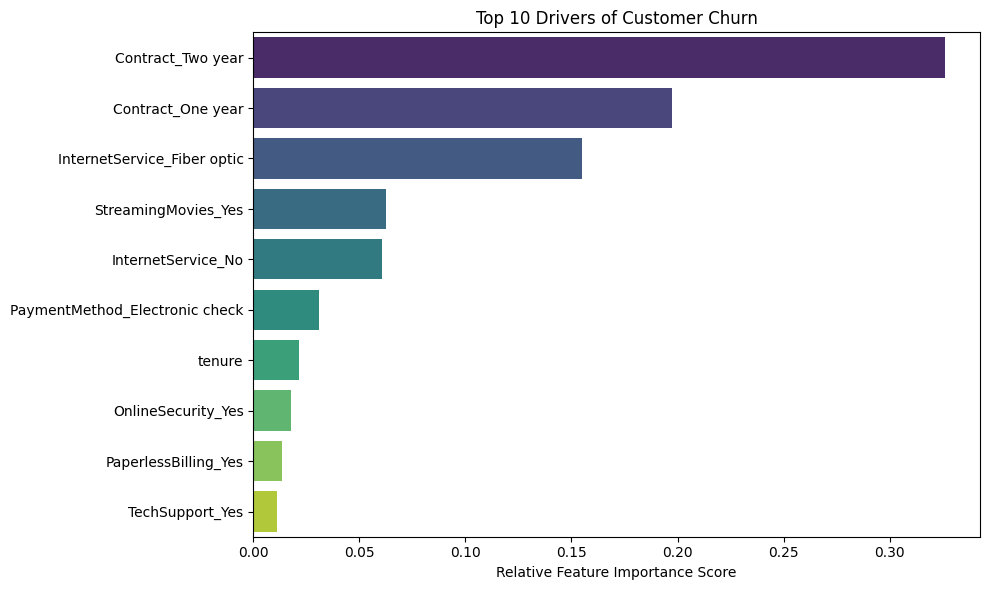

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from xgboost import XGBClassifier
import shap

# 1. LOAD THE REAL TELCO DATASET
print("🔄 Loading Telco Customer Churn dataset...")
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. DATA CLEANING & PREPROCESSING
# Drop customerID as it has no predictive power
df = df.drop(columns=['customerID'])

# TotalCharges has missing spaces ' ' which makes it a text column instead of numeric. Let's fix that.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Handle missing values by filling them with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert the target variable 'Churn' from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. SPLIT DATA INTO FEATURES AND TARGET
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify numerical and categorical columns dynamically
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 4. BUILD THE PIPELINE ENCODER & TRANSFORMER
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Train-test split (80% training, 20% validation) with stratification to keep churn balance stable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and transform features
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Re-extract clean feature names for data plotting later
encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_features

# Convert back to clean pandas DataFrames for interpretation models
X_train_df = pd.DataFrame(X_train_transformed, columns=all_features)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_features)

# 5. ACCOUNT FOR SEVERE CLASS IMBALANCE & TRAIN XGBOOST
# Calculate class ratio: count of non-churned divided by churned users
negative_cases = y_train.value_counts()[0]
positive_cases = y_train.value_counts()[1]
imbalance_ratio = negative_cases / positive_cases

print(f"⚖️ Class distribution calculated. Non-churned vs Churned ratio: {imbalance_ratio:.2f}")

model = XGBClassifier(
    scale_pos_weight=imbalance_ratio, # Penalizes missing the smaller class
    n_estimators=150,
    max_depth=4,
    learning_rate=0.08,
    random_state=42
)
print("🚀 Training the XGBoost Optimization Model...")
model.fit(X_train_df, y_train)

# 6. PIPELINE EVALUATION
y_pred = model.predict(X_test_df)
y_prob = model.predict_proba(X_test_df)[:, 1]

print("\n📊 === Model Performance Evaluation ===")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"🎯 Final Validation ROC-AUC Score: {roc_auc:.4f}\n")

# 7. GENERATE FEATURE IMPORTANCE VISUALIZATION
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices][:10], y=[all_features[i] for i in indices[:10]], palette='viridis')
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Relative Feature Importance Score')
plt.tight_layout()
plt.savefig('churn_drivers.png')
print("💾 Saved feature importance graph as 'churn_drivers.png'")
plt.show()